In [1]:
#Imorting Libraries
import pandas as pd
from datasets import load_dataset
from datetime import datetime
import ast
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
#Data loading
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [3]:
#Data CleanUp
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_posted_date'].dtype

dtype('<M8[us]')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [50]:

median_year_salary = df['salary_year_avg'].median()
median_hour_salary = df['salary_hour_avg'].median()
df_filled = df
df_filled['salary_year_avg'] = df_filled['salary_year_avg'].fillna(median_year_salary)
df_filled['salary_hour_avg'] = df_filled['salary_hour_avg'].fillna(median_hour_salary)
df_filled.loc[:,'salary_year_avg':'salary_hour_avg']
df_unique = df_filled
df_unique = df_unique.drop_duplicates()
print(f"Length Of Original DataFrame: {len(df_filled)}")
print(f"Length Of DataFrame After Dropping Duplicates: {len(df_unique)}")
print(f"Length Of Deleted DataFrame: {len(df_filled)-len(df_unique)}")


Length Of Original DataFrame: 785741
Length Of DataFrame After Dropping Duplicates: 785640
Length Of Deleted DataFrame: 101


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,Costa Rica,2023-08-01 13:37:57,False,False,Costa Rica,year,109500.0,45.98,Netskope,"['gdpr', 'excel']","{'analyst_tools': ['excel'], 'libraries': ['gd..."
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,Sudan,2023-06-26 14:22:54,False,False,Sudan,year,140000.0,45.98,Intelletec,"['mongodb', 'mongodb', 'python', 'r', 'sql', '...","{'analyst_tools': ['tableau'], 'cloud': ['orac..."
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,45.98,Apex Systems,"['sql', 'python']","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,45.98,TikTok,"['sql', 'r', 'python', 'express']","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,45.98,Get It Recruit - Transportation,"['python', 'r', 'alteryx', 'tableau']","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785624,Data Engineer,Data Analytics Engineer (Hybrid),"Mt Prospect, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-08-31 06:02:16,False,True,United States,year,139216.0,45.98,Bosch Group,"['go', 'python', 'r', 'sql', 'oracle', 'window...","{'analyst_tools': ['alteryx', 'power bi', 'tab..."
785641,Data Engineer,Data Engineer,"New York, NY",via Dice,Full-time,False,Georgia,2023-01-04 16:36:07,True,False,United States,year,150000.0,45.98,"Engage Partners, Inc.",NaN,NaN
785648,Data Scientist,Director Data Scientist - Commercial Platforms...,"Pleasant Hill, CA",via Ai-Jobs.net,Full-time,False,"California, United States",2023-04-12 06:02:51,False,True,United States,year,221875.0,45.98,84.51°,"['python', 'azure', 'snowflake', 'spark']","{'cloud': ['azure', 'snowflake'], 'libraries':..."
785682,Data Scientist,Data Scientist für datengetriebene Entwicklung...,"Reutlingen, Germany",via Ai-Jobs.net,Full-time,False,Germany,2023-03-04 06:16:08,False,False,Germany,year,157500.0,45.98,Bosch Group,"['python', 'hadoop', 'spark', 'airflow', 'kube...","{'libraries': ['hadoop', 'spark', 'airflow'], ..."


<Axes: xlabel='job_country'>

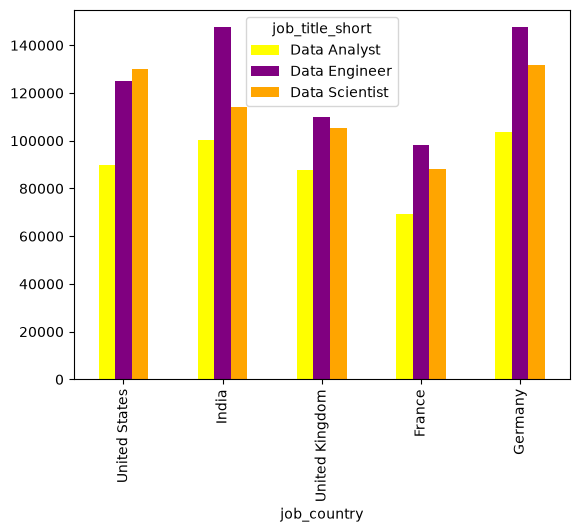

In [58]:
# 1. Grab a random look at 10 rows from the dataset just to see what the data looks like
df.sample(10)

# 2. Make an exact copy of the main dataframe so we don't break the original data
df_new = df.copy()

# 3. Count how often each country appears, take the 5 highest, and save their actual NAMES
# (Note: These country text names are saved in a list-like format)
top_countries = df_new['job_country'].value_counts().head(5).index

# 4. Turn the data into a grid table: 
#    - Row labels (Index) will become the unique country names
#    - Column headers will become the job titles
#    - The main grid values will fill up with the median salaries
df_job_country_salary = df_new.pivot_table(
    values='salary_year_avg',
    index='job_country', 
    columns='job_title_short', 
    aggfunc='median'
)

# 5. .loc[] looks at ROW labels: Keep only the rows whose country name matches 'top_countries'
# (This filters out less popular countries and re-orders the rows by high-to-low popularity)
df_job_country_salary = df_job_country_salary.loc[top_countries]

# 6. Display the filtered table to verify our rows are sorted by top countries
df_job_country_salary

# 7. Create a list of the specific job column headers we actually care about
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# 8. Direct brackets [] look at COLUMN headers: Keep only these 3 specific job columns
# (The '=' sign permanently overwrites the old table, deleting any other job columns)
df_job_country_salary = df_job_country_salary[job_titles]
df_job_country_salary.plot(kind = 'bar' ,color =['yellow','purple','orange'],legend = True)
top_countries

In [73]:
df_usa = df.loc[(df['job_country'] == 'United States')]
df_usa.index.name = 'row_lable_index'
df_usa.reset_index(inplace = True)
df_usa.head(10)
df_usa.set_index()

,row_lable_index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
2,5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '..."
3,6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
4,9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."
5,11,Data Engineer,Data Engineer,"Colorado Springs, CO (+3 others)",via The Muse,Full-time,False,"Texas, United States",2023-11-03 13:06:51,False,True,United States,NaN,NaN,NaN,Philips,"['python', 'qlik']","{'analyst_tools': ['qlik'], 'programming': ['p..."
6,13,Senior Data Engineer,Senior Data Engineer,"New York, NY",via LinkedIn,Full-time,False,"Texas, United States",2023-11-15 13:08:52,True,True,United States,NaN,NaN,NaN,Nayya,"['python', 'sql', 'go', 'ruby', 'ruby', 'javas...","{'cloud': ['aws'], 'other': ['terraform'], 'pr..."
7,17,Data Scientist,Data Science Team Lead,"Laurel, MD",via APL Careers - Johns Hopkins University App...,Full-time,False,Georgia,2023-06-13 13:25:17,False,True,United States,NaN,NaN,NaN,Johns Hopkins Applied Physics Laboratory,"['go', 'apl', 'excel']","{'analyst_tools': ['excel'], 'programming': ['..."
8,26,Data Engineer,Data Engineer,United States,via LinkedIn,Full-time,False,Georgia,2023-09-15 13:56:18,True,False,United States,NaN,NaN,NaN,Infinite Computer Solutions,NaN,NaN
9,27,Data Engineer,"Principal Data Engineer (Lead), Knowledge Grap...","San Francisco, CA",via LinkedIn,Full-time,False,Georgia,2023-02-18 13:31:24,False,False,United States,NaN,NaN,NaN,Altos Labs,"['python', 'r', 'java']","{'programming': ['python', 'r', 'java']}"


In [36]:
df_India = df[(df['job_country'] == 'India')].copy()
# Filter only Indian job postings and create a separate DataFrame copy.

df_India['job_posted_month'] = df_India['job_posted_date'].dt.strftime('%B')
# .dt.strftime() works element-by-element on the entire Series,
# so it converts each date into its full month name (January, February, etc.).Because we are using '%B'
# It is not limited to working on a single row.

df_India_pivot = df_India.pivot_table(
    index='job_posted_month',
    columns='job_title_short',
    aggfunc='size'
)
# Count job postings for each Month × Job Title combination.
# job_posted_month becomes the index and job_title_short becomes columns.


df_India_pivot.reset_index(inplace=True)
# Convert job_posted_month from the index back into a normal column
# so we can use it to create a numeric month value for sorting.


df_India_pivot['job_posted_month_num'] = pd.to_datetime(
    df_India_pivot['job_posted_month'],
    format='%B'
)
# Convert month names (e.g. "January") into datetime values
# so pandas can determine their calendar month numbers.


df_India_pivot['job_posted_month_num'] = df_India_pivot['job_posted_month_num'].dt.month
# Extract the numeric month (January=1, February=2, ..., December=12).


df_India_pivot.sort_values(
    by='job_posted_month_num',
    inplace=True
)
# Sort rows using the numeric month so they appear chronologically
# instead of alphabetically (April, August, December, ...).


df_India_pivot.set_index('job_posted_month', inplace=True)
# Put the month names back as the DataFrame index,
# because that is how we want the final table displayed.


df_India_pivot.drop(columns='job_posted_month_num', inplace=True)
# Remove the temporary numeric month column because it was only needed for sorting.


df_India_pivot
# Final table: months in chronological order with job titles as columns.

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,175,31,628,2132,1444,70,127,448,269,192
February,143,35,433,1631,932,42,94,313,165,157
March,116,37,422,1591,1005,34,96,351,194,180
April,170,32,418,1566,946,54,86,375,194,169
May,103,14,278,1384,837,31,59,329,134,98
June,146,26,367,1632,1129,41,66,427,238,125
July,142,25,457,1528,1123,54,75,359,204,155
August,189,25,618,1407,1157,47,126,343,235,148
September,155,34,630,1508,984,67,85,324,195,132


<Axes: xlabel='job_posted_month'>

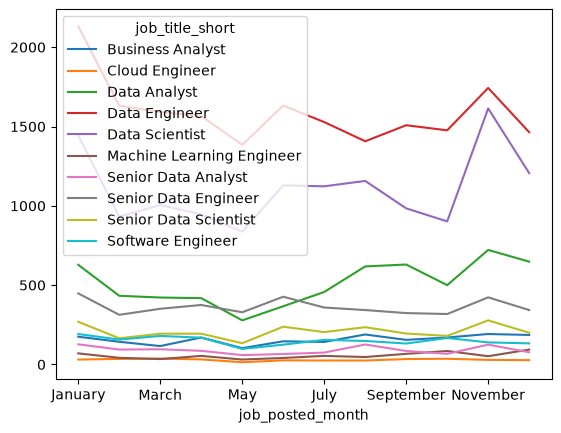

In [37]:
df_India_pivot.plot(kind = 'line')

<Axes: xlabel='job_posted_month'>

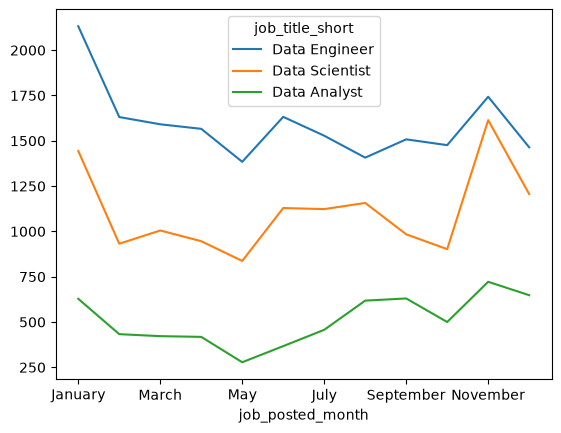

In [41]:
top3_Jobs = df_India['job_title_short'].value_counts().head(3)
# Count each job title and keep the top 3; job titles are the INDEX and counts are the VALUES.

df_India_pivot[top3_Jobs.index].plot(kind='line')
# Use .index to get the top 3 job-title NAMES and use them to select matching columns from the pivot table.

(0.0, 22000.0)

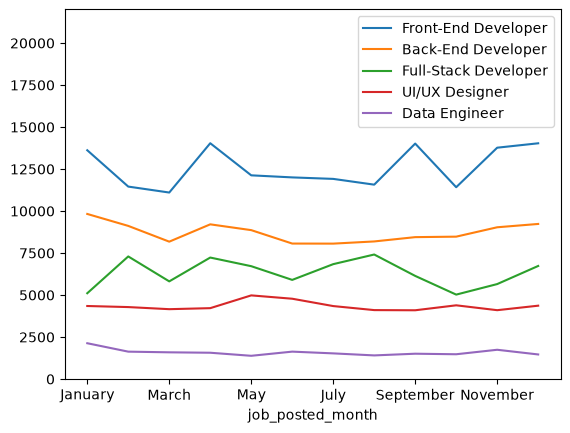

In [66]:
from matplotlib import pyplot as plt
# Import pyplot from Matplotlib for creating and customizing plots.

df_India_pivot_Software = pd.read_csv(
    'https://lukeb.co/software_csv',
    index_col='job_posted_month'
)
# Load the Software job data from the CSV URL, using job_posted_month as the index.

df_India_pivot_merged = df_India_pivot.merge(
    df_India_pivot_Software,
    on='job_posted_month'
)
# Merge the India and Software DataFrames using job_posted_month as the common column/index.

df_India_pivot_merged.sum()
# Yes, aggregation functions like .sum() can be applied directly to a DataFrame.
# It adds values down each numeric column and returns one total for each column.

top_5 = df_India_pivot_merged.sum().sort_values(
    ascending=False
).head()
# Calculate each job title's total, sort totals from highest to lowest, and keep the top 5.

df_India_pivot_merged[top_5.index].plot(kind='line')
# Select the top 5 job-title columns and plot their values as lines.

plt.ylim(0, 22000)
# Set the y-axis range from 0 to 22,000.

<Axes: ylabel='job_posted_month'>

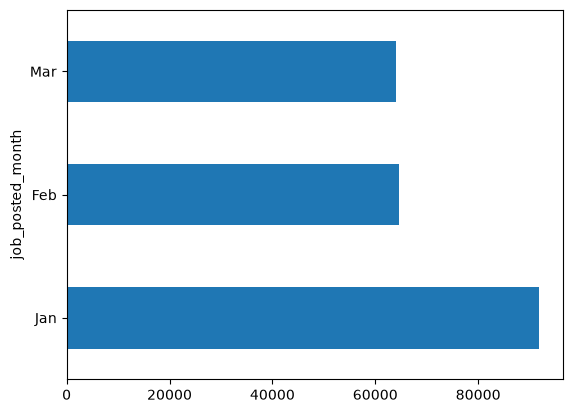

In [5]:
# --- APPROACH 1: FILTERING DATA USING A DICTIONARY COMPREHENSION LOOP ---
# 1. Create a new column 'job_posted_month' by extracting the short month name (e.g., 'Jan', 'Feb') from the 'job_posted_date' column.
df['job_posted_month'] = df['job_posted_date'].dt.strftime('%b')

# 2. Get a list of all unique month names present in the dataset to use as iteration keys.
months = df['job_posted_month'].unique()

# 3. Create a dictionary of dataframes using a loop. For every month, Pandas scans the entire 'df' 
#    from top to bottom to filter out rows matching that specific month.
dict_months = {month: df[df['job_posted_month'] == month] for month in months}

# 4. Combine (concatenate) the separate dataframes for 'Jan', 'Feb', and 'Mar' back together into a single Quarter 1 dataframe.
Quarter1_concated_df = pd.concat([dict_months['Jan'], dict_months['Feb'], dict_months['Mar']], ignore_index=True)

# 5. Display the combined Quarter 1 dataframe to verify the contents.
Quarter1_concated_df

# 6. Count how many jobs are posted in each month within Quarter 1 and plot it as a horizontal bar chart.
Quarter1_concated_df['job_posted_month'].value_counts().plot(kind='barh')

In [ ]:
# --- WHY WE SWITCHED FROM APPROACH 1 TO APPROACH 2 ---
# In Approach 1, we used a dictionary comprehension loop. This forced Pandas to perform 
# a "Boolean Mask" scan across the entire dataset repeatedly for every single month 
# (e.g., scanning 100k rows 12 separate times). This is highly inefficient (O(N * M) complexity).
#
# We switched to Approach 2 using 'groupby()' because it scans the dataset exactly ONCE. 
# It buckets the rows into their respective months simultaneously in memory (O(N) complexity). 
# This makes the code execute significantly faster, drastically saving time and computing 
# power as the dataset grows into hundreds of thousands or millions of rows.

In [6]:
# --- APPROACH 2: FILTERING DATA USING PANDAS GROUPBY (OPTIMIZED) ---
# 1. Use 'groupby' to scan the dataframe exactly once, automatically categorizing all rows by their month.
# 2. Convert the groups into a list of tuples, and cast it into a dictionary where keys are months and values are dataframes.
dict_months = dict(list(df.groupby('job_posted_month')))

# 3. Combine the 'Jan', 'Feb', and 'Mar' dataframes from our new dictionary into a single Quarter 1 dataframe.
Quarter1_concated_df = pd.concat([dict_months['Jan'], dict_months['Feb'], dict_months['Mar']], ignore_index=True)

# 4. Display the finalized Quarter 1 dataframe.
Quarter1_concated_df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",Jan
1,Data Scientist,Data Scientist,"Zaventem, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-31 13:53:38,False,False,Belgium,NaN,NaN,NaN,Devoteam,"['r', 'python', 'sql', 'pandas', 'numpy', 'sci...","{'libraries': ['pandas', 'numpy', 'scikit-lear...",Jan
2,Data Engineer,Data Engineer,"Fort Worth, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-25 13:24:01,False,False,United States,NaN,NaN,NaN,Programmers.io,"['sql', 'python']","{'programming': ['sql', 'python']}",Jan
3,Data Engineer,Data Engineer,"San Mateo, CA",via LinkedIn,Full-time,False,"California, United States",2023-01-28 13:07:30,False,True,United States,NaN,NaN,NaN,Verkada,"['sql', 'python', 'aws', 'looker']","{'analyst_tools': ['looker'], 'cloud': ['aws']...",Jan
4,Data Scientist,Data Scientist,"São Paulo, State of São Paulo, Brazil",via BeBee,Full-time,False,Brazil,2023-01-03 23:02:27,False,False,Brazil,NaN,NaN,NaN,Mars,"['python', 'sql', 'azure']","{'cloud': ['azure'], 'programming': ['python',...",Jan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220479,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete...",Mar
220480,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi...",Mar
220481,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}",Mar
220482,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh...",Mar


In [9]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [15]:
Quarter1_concated_df.to_clipboard(sep = ',')
df1 = pd.read_excel('new_file.xlsx')
df1

In [29]:
df_salary_notNaN = df[pd.notna(df['salary_year_avg'])].copy()

def BonusRateMul(salary):
    return salary*1.3
    
df_salary_notNaN['salary_year_avg_inflated'] = df_salary_notNaN['salary_year_avg'].apply(BonusRateMul)
df_salary_notNaN[['salary_year_avg_inflated','salary_year_avg']]


df_salary_notNaN['salary_year_avg_inflated'] = df_salary_notNaN['salary_year_avg'].apply(lambda salary: salary/1.3)

,salary_year_avg_inflated,salary_year_avg
28,142350.0,109500.0
77,182000.0,140000.0
92,156000.0,120000.0
100,296688.6,228222.0
109,115700.0,89000.0
...,...,...
785624,180980.8,139216.0
785641,195000.0,150000.0
785648,288437.5,221875.0
785682,204750.0,157500.0


In [47]:
# Bonus: Give Senior jobs a 5% increase and other jobs a 3% increase

df_salary = df[pd.notna(df['salary_year_avg'])].copy()
# Keep only rows where salary_year_avg is not missing
# .copy() creates a separate DataFrame


def Projected_Salary(row):
    # Calculate the inflated/projected salary for each row

    if 'Senior' in row['job_title_short']:
        return 1.05 * row['salary_year_avg']
        # If the job title contains 'Senior', increase salary by 5%

    else:
        return 1.03 * row['salary_year_avg']
        # For all other jobs, increase salary by 3%


df_salary['salary_year_avg_inflated'] = df_salary.apply(
    Projected_Salary,
    axis=1
)
# Apply the Projected_Salary function to every row
# axis=1 means the function receives one row at a time
# Store the calculated salary in a new column


df_salary[
    ['job_title_short', 'salary_year_avg', 'salary_year_avg_inflated']
].loc[
    (df['job_title_short'] == 'Senior Data Analyst') |
    (df['job_title_short'] == 'Data Analyst')
]
# Select the job title, original salary, and inflated salary columns
# Keep only Senior Data Analyst and Data Analyst rows

,job_title_short,salary_year_avg,salary_year_avg_inflated
109,Data Analyst,89000.0,91670.00
180,Data Analyst,90250.0,92957.50
410,Data Analyst,133285.0,137283.55
982,Senior Data Analyst,85000.0,89250.00
988,Data Analyst,62623.0,64501.69
...,...,...,...
784812,Senior Data Analyst,170000.0,178500.00
784882,Data Analyst,87500.0,90125.00
784891,Senior Data Analyst,175000.0,183750.00
785187,Data Analyst,111175.0,114510.25


Task was destroyed but it is pending!
task: <Task pending name='Task-489' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-490' coro=<Kernel.shell_main() running at C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\transforms.py:193: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-490' coro=<Kernel.shell_main() running at C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[T

<Axes: >

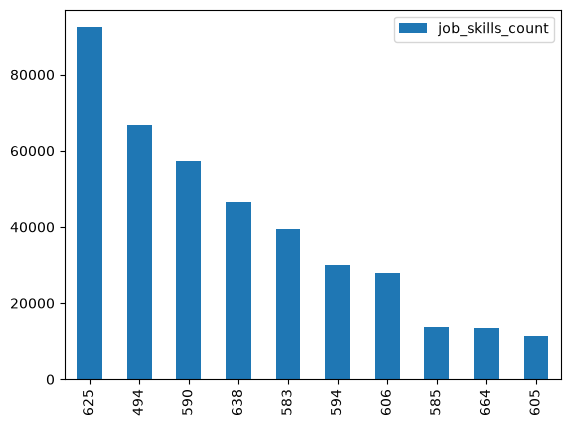

In [65]:
import ast
# Import ast so we can convert string representations of lists into actual Python lists


df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
# Convert job_skills from strings like "['sql', 'excel']" into actual lists
# Keep NaN/other non-string values unchanged


df_exploded = df.explode('job_skills')
# Split each list into separate rows
# Example: ['sql', 'excel'] → sql and excel on separate rows


skills_count = df_exploded.groupby(
    ['job_title_short', 'job_skills']
).size()
# Group by job title and individual skill
# .size() counts how many times each skill appears for each job title
# The result is a Series


df_skills = skills_count.reset_index(name='job_skills_count')
# Convert the Series into a DataFrame
# reset_index() also turns the grouped columns back into normal columns
# 'job_skills_count' becomes the name of the count column


df_skills = df_skills.sort_values(
    by='job_skills_count',
    ascending=False
)
# Sort skills from highest count to lowest count


job_title = 'Data Analyst'
# Choose the job title we want to analyze


df_final = df_skills[
    df_skills['job_title_short'] == job_title
].head(10)
# Keep only the selected job title
# .head(10) gets the top 10 most common skills


from matplotlib import pyplot as plt
# Import matplotlib's pyplot module for plotting


df_final.plot(
    kind='barh',
    x='job_skills',
    y='job_skills_count'
)
# Create a horizontal bar chart
# x = skill names
# y = number of job postings containing each skill


plt.gca().invert_yaxis()
# Reverse the y-axis so the highest-count skill appears at the top

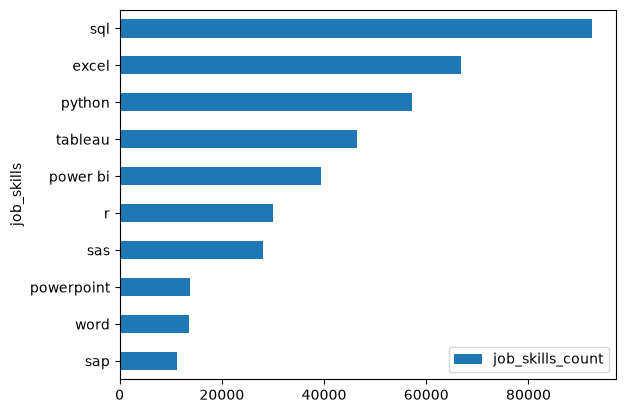

Text(0, 0.5, 'Skills_Counts')

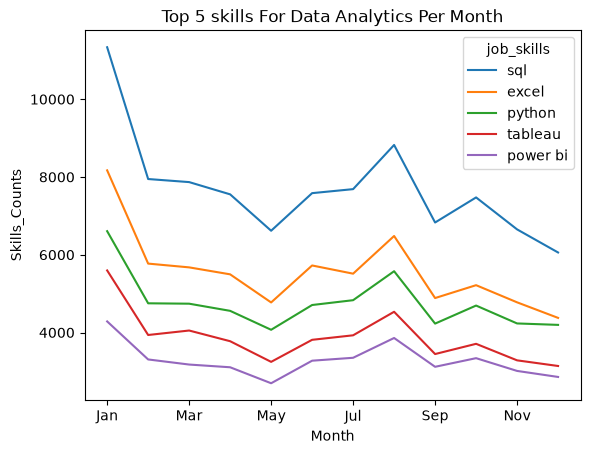

In [41]:
# Convert job_skills from a string like "['SQL', 'Python']" into an actual Python list
# apply() runs the lambda on every value in the column
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Keep only Data Analyst job postings
df_DataAnalyst = df[df['job_title_short'] == 'Data Analyst'].copy()

# Extract the month number (1-12) from the job posting date
df_DataAnalyst['job_posted_month'] = df_DataAnalyst['job_posted_date'].dt.month

# Create a separate row for each skill in each job posting
df_exploded_DA_JobSkills = df_DataAnalyst.explode('job_skills')

# Create a month × skill table and count how many times each skill appears
df_exploded_DA_JobSkills = df_exploded_DA_JobSkills.pivot_table(
    index='job_posted_month',
    columns='job_skills',
    aggfunc='size'
)

# Add a 'Total' row that contains the total count of each skill across all months
# This helps us find which skills appear most frequently overall
df_exploded_DA_JobSkills.loc['Total'] = df_exploded_DA_JobSkills.sum()

# Sort the columns by their Total count from highest to lowest
# .index gives us the skill names in that sorted order
# Then df[...] rearranges ALL rows using those column names
# So the most frequently requested skills come first
df_exploded_DA_JobSkills = df_exploded_DA_JobSkills[
    df_exploded_DA_JobSkills.loc['Total'].sort_values(ascending=False).index
]

# Remove the Total row because we only want monthly data in the final table
df_exploded_DA_JobSkills = df_exploded_DA_JobSkills.drop('Total')

# Convert the index (job_posted_month) back into a normal column
df_exploded_DA_JobSkills = df_exploded_DA_JobSkills.reset_index()

# Convert month numbers (1, 2, 3...) into month names (Jan, Feb, Mar...)
df_exploded_DA_JobSkills['job_posted_month_name'] = (
    df_exploded_DA_JobSkills['job_posted_month']
    .apply(lambda x: pd.to_datetime(str(x), format='%m').strftime('%b'))
)

# Make the month name the index for easier plotting
df_exploded_DA_JobSkills = df_exploded_DA_JobSkills.set_index(
    'job_posted_month_name'
)

# Remove the original month-number column because month names are now used as the index
df_exploded_DA_JobSkills = df_exploded_DA_JobSkills.drop(
    columns='job_posted_month'
)

# Select the first 5 columns (the 5 most frequently appearing skills) and create a line chart
df_exploded_DA_JobSkills.iloc[:, :5].plot(kind='line')

# Add chart title and axis labels
plt.title('Top 5 Skills for Data Analysts Per Month')
plt.xlabel('Month')
plt.ylabel('Skill Counts')

In [31]:
import ast

df_new = df.copy()

# Convert job_skills from string list → actual Python list
df_new['job_skills'] = df_new['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# One row per individual skill
df_exploded = df_new.explode('job_skills')

# Count each skill for each job title
skills_count = df_exploded.groupby(
    ['job_title_short', 'job_skills']
).size()

# Convert grouped Series → DataFrame and name the count column
df_skills_count = skills_count.reset_index(name='Skills_count')

# Sort so highest skill counts come first
df_skills_count = df_skills_count.sort_values(
    by='Skills_count',
    ascending=False
)

# Job titles we want separate charts for
titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# Create 3 rows × 1 column of plots
# fig = whole figure, ax = array containing the 3 subplot Axes
fig, ax = plt.subplots(3, 1)

# enumerate() gives both: i = position (0,1,2), title = job title
for i, title in enumerate(titles):

    # Filter one job title and keep its top 5 skills
    df_plot = df_skills_count[
        df_skills_count['job_title_short'] == title
    ].head()

    # Plot this job title on its corresponding subplot
    # ax=ax[i] tells pandas WHICH subplot to draw on
    df_plot.plot(
        kind='barh',
        x='job_skills',
        y='Skills_count',
        title=title,
        legend=False,
        ax=ax[i]
    )

    # ax[i] = current subplot; invert its y-axis
    # Same idea as plt.gca(), but we explicitly choose the Axes
    ax[i].invert_yaxis()

    # Remove the y-axis label
    ax[i].set_ylabel('')

    # Keep the same x-axis range for all 3 charts
    ax[i].set_xlim(0, 120000)

# Title for the entire figure
fig.suptitle('Count Of Top Skills In Job Posting', fontsize=20)

# Automatically adjust spacing so plots don't overlap
fig.tight_layout()

0 Data Analyst
1 Data Engineer
2 Data Scientist


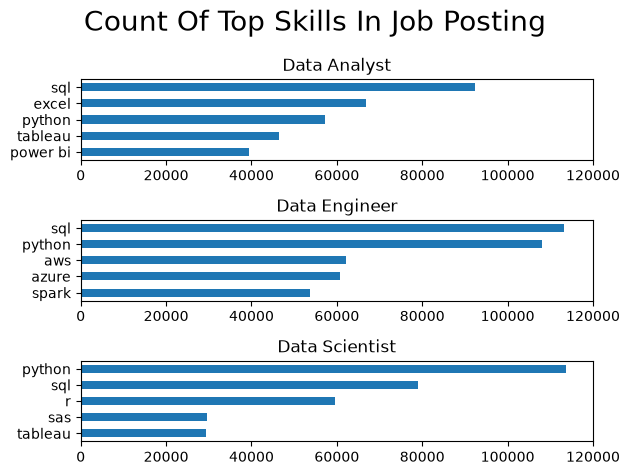

<Axes: >

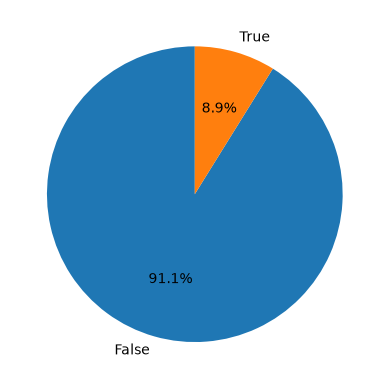

In [77]:
df['job_work_from_home'].value_counts().plot(kind = 'pie',startangle = 90, autopct = '%1.1f%%')

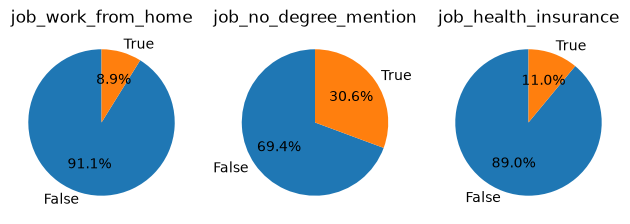

In [89]:
# Columns we want to visualize as separate pie charts
columns = [
    'job_work_from_home',
    'job_no_degree_mention',
    'job_health_insurance'
]

# Create 1 row × 3 columns of subplots
# figure = entire figure, ax = array of the 3 subplot Axes
figure, ax = plt.subplots(1, 3)

# enumerate() gives i = subplot position (0,1,2) and column = column name
for i, column in enumerate(columns):

    # value_counts() → count each True/False value
    # kind='pie' → make a pie chart
    # startangle=90 → start the first slice from 90° (top)
    # autopct='%1.1f%%' → show percentages with 1 decimal place
    # title=column → use the column name as chart title
    # ax=ax[i] → put the chart in the current subplot
    df[column].value_counts().plot(
        kind='pie',
        startangle=90,
        autopct='%1.1f%%',
        title=column,
        ax=ax[i]
    )

# Automatically adjust spacing between the 3 charts
figure.tight_layout()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


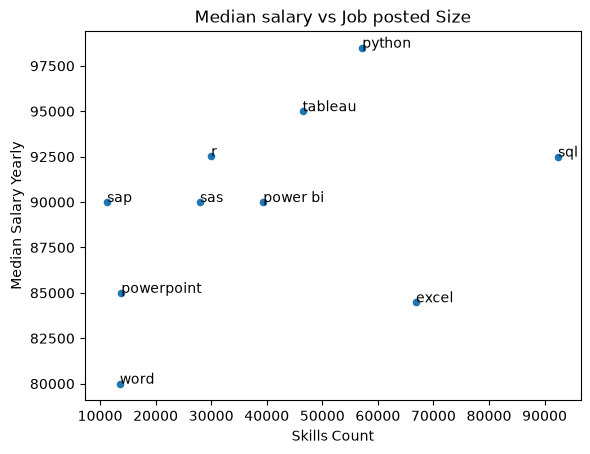

In [73]:
df_test = df_exploded_da.groupby('job_skills')['salary_year_avg'].agg('median').rename('median_salary')
# 1. Group by each skill and calculate the median salary for that skill.

df_test_new = df_exploded_da['job_skills'].value_counts().rename('skill_count').head(10)
# 2. Count how many times each skill appears and keep the top 10 skills.

df_result = df_test.merge(df_test_new, on='job_skills', how='inner')
# 3. Merge the median salary and skill count using job_skills as the common column.

df_result = df_result.sort_values(by='skill_count', ascending=False)
# 4. Sort the merged result so the most frequently appearing skills come first.

for i, skill in enumerate(df_result['job_skills']):
    plt.text(df_result['skill_count'].iloc[i],
             df_result['median_salary'].iloc[i],
             skill)
# 5. Go through each skill and put its name at the corresponding x and y coordinates.

In [ ]:
# Switched from creating two separate DataFrames and merging them to using one groupby().agg(),
# because both skill_count and median_salary can be calculated together in the same grouping operation.

([Text(94570.57822580644, 93033.27422369093, 'sql'),
  Text(70706.90181451614, 85012.27422369091, 'excel'),
  Text(62351.66572580645, 99126.05696178616, 'python'),
  Text(52103.61532258065, 95626.05696178615, 'tableau'),
  Text(45710.34475806452, 90626.05696178616, 'power bi'),
  Text(29216.88064516129, 91934.4193683604, 'r'),
  Text(30432.74798387097, 89870.83305883658, 'sas'),
  Text(22002.753225806453, 85819.42983960346, 'powerpoint'),
  Text(17141.07953629032, 80533.27422369093, 'word'),
  Text(15467.766532258065, 89778.05032074134, 'sap'),
  Text(16141.6212953629, 99787.97784633737, 'azure'),
  Text(16522.564919354838, 96561.69174436537, 'oracle'),
  Text(12066.087500000001, 101391.4431778842, 'aws'),
  Text(13657.2625, 92952.78866480266, 'sql server'),
  Text(9658.0185483871, 89240.7995799231, 'go'),
  Text(13199.78508064516, 94712.73341103204, 'flow'),
  Text(28837.272983870957, 93433.34353007966, 'vba'),
  Text(10982.41108870968, 103798.81972055584, 'looker'),
  Text(13628.3288

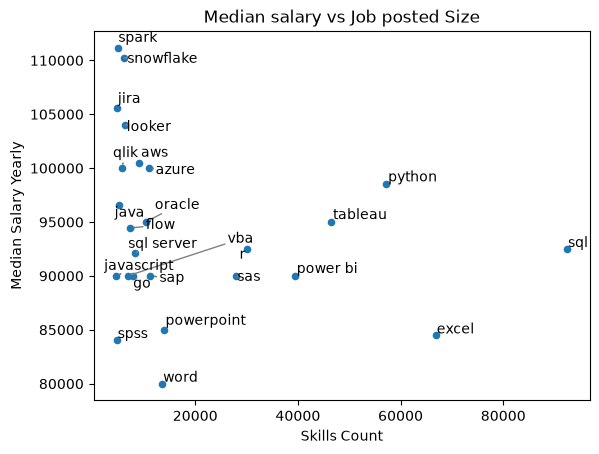

In [83]:
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
# 1. Convert job_skills from a string representation of a list into an actual Python list.

df_da = df.copy()
# 2. Create a separate DataFrame so the original df is not filtered.

df_da = df_da[df_da['job_title_short'] == 'Data Analyst']
# 3. Keep only Data Analyst job postings.

df_exploded = df_da.explode('job_skills')
# 4. Create one row for each individual skill in a job posting.

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'size'),
    median_salary=('salary_year_avg', 'median')
)
# 5. Group by skill and calculate BOTH the number of postings and median salary in one operation.
skill_counts = 25
skill_stats = skill_stats.sort_values(
    by='skill_count',
    ascending=False
).head(skill_counts)
# Keep only the 10 most frequently occurring skills.

skill_stats.plot(
    kind='scatter',
    x='skill_count',
    y='median_salary',
    title='Median salary vs Job posted Size'
)
# Create a scatter plot using skill count on X and median salary on Y.

plt.xlabel('Skills Count')
plt.ylabel('Median Salary Yearly')
# Give meaningful labels to both axes.

from  adjustText import adjust_text

texts = []

for i, skill in enumerate(skill_stats.index):
    texts.append(plt.text(
        skill_stats['skill_count'].iloc[i],
        skill_stats['median_salary'].iloc[i],
        skill
    ))
adjust_text(texts,arrowprops = dict(arrowstyle= '->',color = 'grey' ))
# Add the skill name next to each scatter point and automatically adjust
# the labels to reduce overlap.



([Text(94407.6185483871, 92816.45783923921, 'sql'),
  Text(70414.31512096772, 84795.45783923921, 'excel'),
  Text(61959.08104838708, 98871.51736304874, 'python'),
  Text(51673.9943548387, 95371.51736304874, 'tableau'),
  Text(45228.872983870955, 90371.51736304874, 'power bi'),
  Text(30589.88556451613, 92825.47024197048, 'r'),
  Text(30247.566532258068, 90297.97024197048, 'sas'),
  Text(21380.543548387097, 85486.26951187376, 'powerpoint'),
  Text(16868.862802419353, 80316.45783923921, 'word'),
  Text(13709.53185483871, 90297.97024197048, 'sap')],
 [])

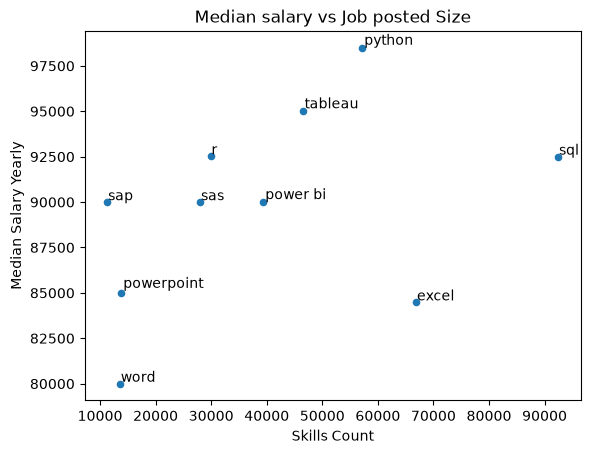

   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   -- ------------------------------------- 2.4/37.4 MB 11.4 MB/s eta 0:00:04
   ----- ---------------------------------- 4.7/37.4 MB 11.5 MB/s eta 0:00:03
   ------- -------------------------------- 6.8/37.4 MB 11.6 MB/s eta 0:00:03
   --------- ------------------------------ 9.2/37.4 MB 11.1 MB/s eta 0:00:03
   ------------ --------------------------- 11.8/37.4 MB 11.2 MB/s eta 0:00:03
   --------------- ------------------------ 14.2/37.4 MB 11.3 MB/s eta 0:00:03
   ----------------- ---------------------- 16.5/37.4 MB 11.4 MB/s eta 0:00:02
   ------------------- -------------------- 18.4/37.4 MB 11.2 MB/s eta 0:00:02
   --------------------- ------------------ 20.4/37.4 MB 10.9 MB/s eta 0:00:02
   ------------------------ --------------- 22.8/37.4 MB 10.8 MB/s eta 0:00:02
   ------------------------- -------------- 24.1/37.4 MB 10.5 MB/s eta 0:00:02
   ---------------------------- ----------- 26.2/37.4 MB 10.4 MB/

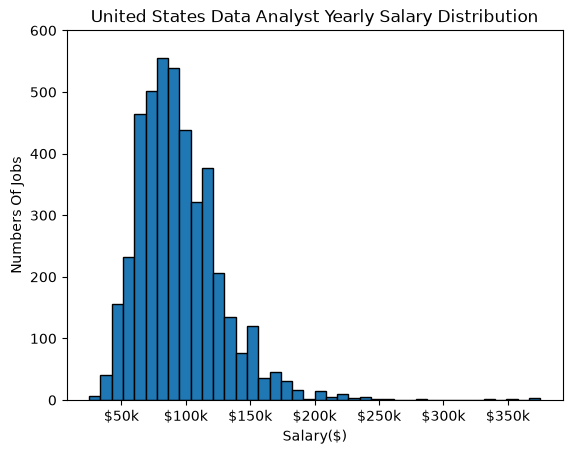

In [56]:
df_DA_US  = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()

df_DA_US['salary_year_avg'].plot(kind = 'hist', bins = 40,edgecolor = 'black')
plt.ylim(0,600)

plt.title('United States Data Analyst Yearly Salary Distribution')
plt.ylabel('Numbers Of Jobs')
plt.xlabel('Salary($)')

from matplotlib.ticker import FuncFormatter

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1000:.0f}k')
)

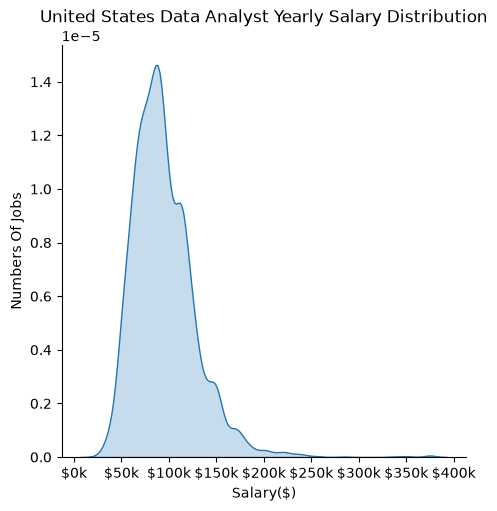

In [59]:
sns.displot(data = df_DA_US['salary_year_avg'],kind = 'kde',fill = True)

plt.title('United States Data Analyst Yearly Salary Distribution')
plt.ylabel('Numbers Of Jobs')
plt.xlabel('Salary($)')

from matplotlib.ticker import FuncFormatter

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1000:.0f}k')
)

In [52]:
from matplotlib.ticker import FuncFormatter
# FuncFormatter lets us customize how numbers appear on the axis

titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[
    (df['job_title_short'].isin(titles)) &   # Keep only these job titles
    (df['job_country'] == 'United States')   # Keep only US jobs
].copy()

df_US = df_US.dropna(subset=['salary_year_avg'])
# Remove rows where salary is missing

jobs_spread = [
    df_US[df_US['job_title_short'] == title]['salary_year_avg']
    for title in titles
]
# Create one salary Series for each job title
# Result = [Analyst salaries, Engineer salaries, Scientist salaries]

plt.boxplot(
    jobs_spread,
    label = titles,
    orientation='horizontal'  # Horizontal boxplot; replaces old vert=False
)

plt.title('Salary Distribution In United States')

plt.xlim(0, 600000)
# Horizontal boxplot → salary is on X-axis → use xlim()

ax = plt.gca()
# Get the current Axes object

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'${int(y/1000)}k')
)
# set_major_formatter() → change how X-axis numbers are displayed
# Divide by 1000 and add $ + k: 60000 → $60k

plt.show()

'''"The Box Plot Rule:
Every section holds the exact same number of people (25%).
Long section = Spread out (People have wildly different numbers).
Short section = Packed tight (People have almost identical numbers)."'''

TypeError: boxplot() got an unexpected keyword argument 'lable'. Did you mean 'label'?

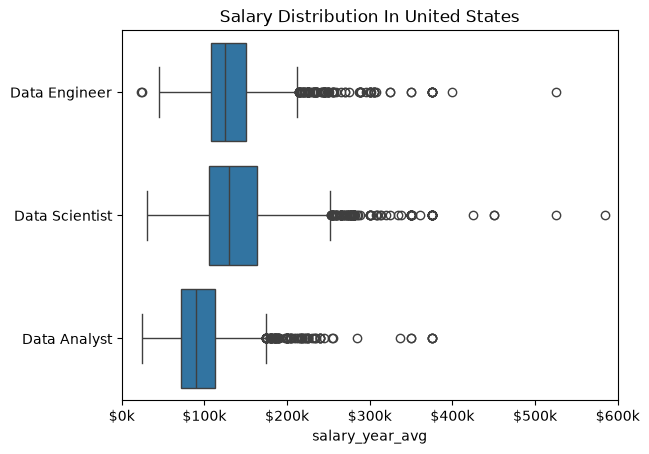

In [54]:
sns.boxplot(df_US,x = 'salary_year_avg',y='job_title_short')

plt.title('Salary Distribution In United States')

plt.xlim(0, 600000)
# Horizontal boxplot → salary is on X-axis → use xlim()

plt.ylabel('')
ax = plt.gca()
# Get the current Axes object

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'${int(y/1000)}k')
)
# set_major_formatter() → change how X-axis numbers are displayed
# Divide by 1000 and add $ + k: 60000 → $60k

plt.show()

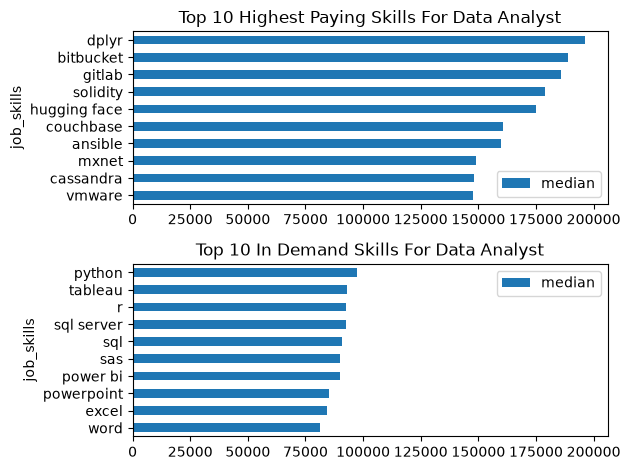

In [9]:
# Keep only Data Analyst jobs in the United States
df_US_DA = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'United States')
].copy()

# Remove rows where salary is missing
df_US_DA = df_US_DA.dropna(subset=['salary_year_avg'])

# Convert job_skills from string "['SQL', 'Python']" into an actual list
df_US_DA['job_skills'] = df_US_DA['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Split each skill into its own row
df_US_DA_exploded = df_US_DA.explode('job_skills')

# For each skill: count how often it appears and find its median salary
df_US_DA_grouped = df_US_DA_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

# Get top 10 skills by demand, then sort those 10 by salary
df_US_DA_counts = (
    df_US_DA_grouped
    .sort_values(by='count', ascending=False)  # First: find most demanded skills
    .head(10)                                  # Keep only top 10
    .sort_values(by='median', ascending=False) # Then: arrange those 10 by salary
)

# Get top 10 highest-paying skills
df_US_DA_median = (
    df_US_DA_grouped
    .sort_values(by='median', ascending=False)
    .head(10)
)

# Create 2 rows of plots
fig, ax = plt.subplots(2, 1)

# Plot median salary of the top 10 highest-paying skills
df_US_DA_median[::-1].plot(
    kind='barh',
    y='median',
    title='Top 10 Highest Paying Skills For Data Analyst',
    ax=ax[0]
)

# Plot median salary of the top 10 in-demand skills
df_US_DA_counts[::-1].plot(
    kind='barh',
    y='median',
    title='Top 10 In Demand Skills For Data Analyst',
    ax=ax[1]
)



# Give both charts the same salary-axis range for easy comparison
ax[1].set_xlim(ax[0].get_xlim())

# Automatically adjust spacing between charts
fig.tight_layout()

plt.show()

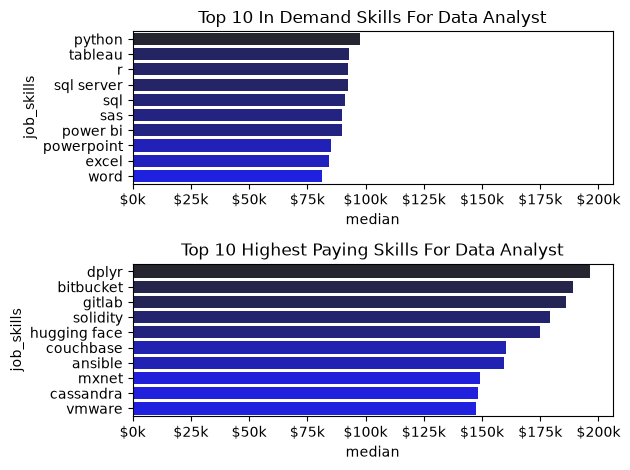

In [28]:
fig, ax = plt.subplots(2, 1)

sns.barplot(data = df_US_DA_counts,x = 'median',y = df_US_DA_counts.index,ax = ax[0],hue = 'median',palette = 'dark:b_r',legend = False)
ax[0].set_title('Top 10 In Demand Skills For Data Analyst')
ax[0].xaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))


sns.barplot(data = df_US_DA_median,x = 'median',y = df_US_DA_median.index,ax = ax[1],hue = 'median',palette = 'dark:b_r',legend = False)
ax[1].set_title('Top 10 Highest Paying Skills For Data Analyst')
ax[1].xaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f'${int(y/1000)}k')
)

ax[0].set_xlim(ax[1].get_xlim())
fig.tight_layout()

<Axes: >

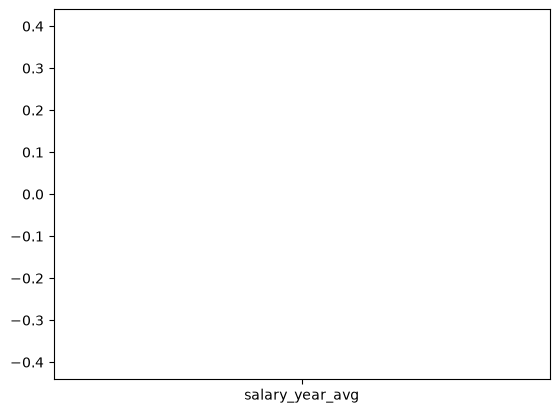

In [39]:
sns.boxplot(data = jobs_spread,vert = False)

In [25]:
df_us_da.info()

<class 'pandas.DataFrame'>
Index: 67816 entries, 36 to 785705
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        67816 non-null  str           
 1   job_title              67816 non-null  str           
 2   job_location           67582 non-null  str           
 3   job_via                67809 non-null  str           
 4   job_schedule_type      67107 non-null  str           
 5   job_work_from_home     67816 non-null  bool          
 6   search_location        67816 non-null  str           
 7   job_posted_date        67816 non-null  datetime64[us]
 8   job_no_degree_mention  67816 non-null  bool          
 9   job_health_insurance   67816 non-null  bool          
 10  job_country            67816 non-null  str           
 11  salary_rate            8442 non-null   str           
 12  salary_year_avg        4350 non-null   float64       
 13  salary_hour_avg

<Axes: xlabel='count', ylabel='job_location'>

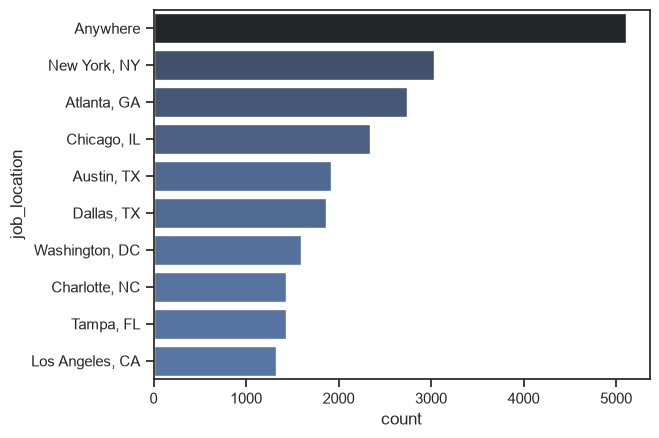

In [34]:
import seaborn as sns
sns.set_theme(style = 'ticks')

df_us_da = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'United States')
].copy()
counts_by_location = df_us_da['job_location'].value_counts().head(10).to_frame().copy()

sns.barplot(counts_by_location,x = 'count',y='job_location',hue = 'count',palette = 'dark:b_r',legend = False)


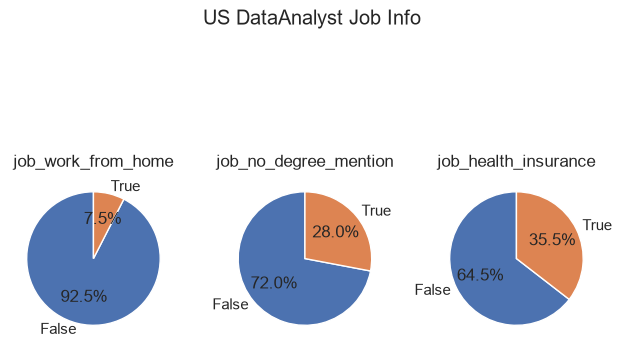

In [40]:
fig, ax = plt.subplots(1,3)


to_plot_list = ['job_work_from_home','job_no_degree_mention','job_health_insurance']

for i,to_plot in enumerate(to_plot_list):
    df_us_da[to_plot].value_counts().plot(kind = 'pie', startangle = 90,autopct = '%1.1f%%',title = to_plot, ax = ax[i])

fig.suptitle('US DataAnalyst Job Info')
fig.tight_layout()


Text(0.5, 1.0, 'US Top 10 Data Analyst Companies Job Post Counts')

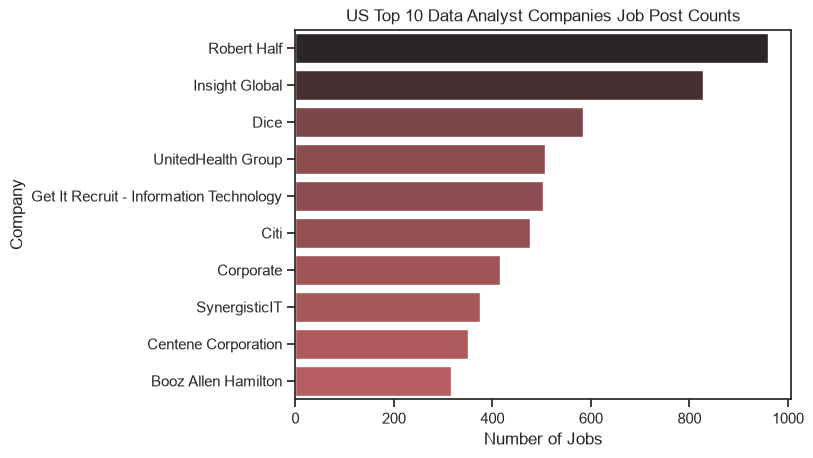

In [54]:
company_counts = df_us_da['company_name'].value_counts().head(10).to_frame().copy() 

sns.barplot(company_counts,x = 'count', y='company_name',hue = 'count',palette = 'dark:r_r',legend = False)

plt.xlabel('Number of Jobs')
plt.ylabel('Company')
plt.title('US Top 10 Data Analyst Companies Job Post Counts')
